# ED Triage Severity Classifier (ESI Prediction)

**Part of:** ER-Priority-Scheduler project

This notebook trains a classifier to predict Emergency Severity Index (ESI)
from patient vitals and presentation data. It feeds severity scores into the
companion **ED Scheduling Simulation** notebook, which is the primary
contribution of this project.

**Note on data:** All patient records are synthetically generated using
clinically-informed rules (vital sign thresholds, shock index, etc. based
on real ESI triage criteria), not real hospital data. Real ED records
require IRB approval and hospital data-sharing agreements, which are out
of scope here. The synthetic generator lets us test the scheduling
algorithm under realistic patient-mix assumptions without needing PHI.

Several engineered features below (e.g. `Shock_Index`, `Critical_Score`)
mirror the same clinical logic used to *generate* the ESI label in the
first place. So model accuracy should be read as "how well can we recover
clinically sound decision rules from vitals," not as a real-world
generalization claim. This is called out explicitly in the diagnostics
section.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

np.random.seed(42)

In [ ]:
df = pd.read_csv("ed_triage_synthetic.csv")

print(f"Loaded {len(df):,} patient records")
df.head()

Loaded 10,000 patient records


,Heart_Rate,Systolic_BP,Age,SpO2,Pain_Score,Mental_Status,Chief_Complaint,Trauma,Arrival_Mode,Chronic_Condition,Symptom_Duration,Previous_ER_Visits,ESI_Level
0,99,117,41,97,6,Alert,Fever,1,Ambulance,0,Short,4,5
1,50,132,72,95,2,Unresponsive,Chest Pain,0,Walk-in,0,Short,3,5
2,87,119,61,93,6,Alert,Trauma,1,Ambulance,0,Medium,1,4
3,80,121,79,95,9,Pain,Headache,0,Walk-in,0,Short,1,3
4,91,128,88,93,0,Alert,Chest Pain,0,Walk-in,1,Medium,2,5


## Exploratory Data Analysis

Quick sanity checks on shape, missing values, class balance, and how raw
vitals correlate with ESI level before we engineer anything.

Shape: (10000, 13)

Missing values:
 0 total

ESI distribution:
ESI_Level
1    0.0453
2    0.1195
3    0.2209
4    0.3456
5    0.2687
Name: proportion, dtype: float64


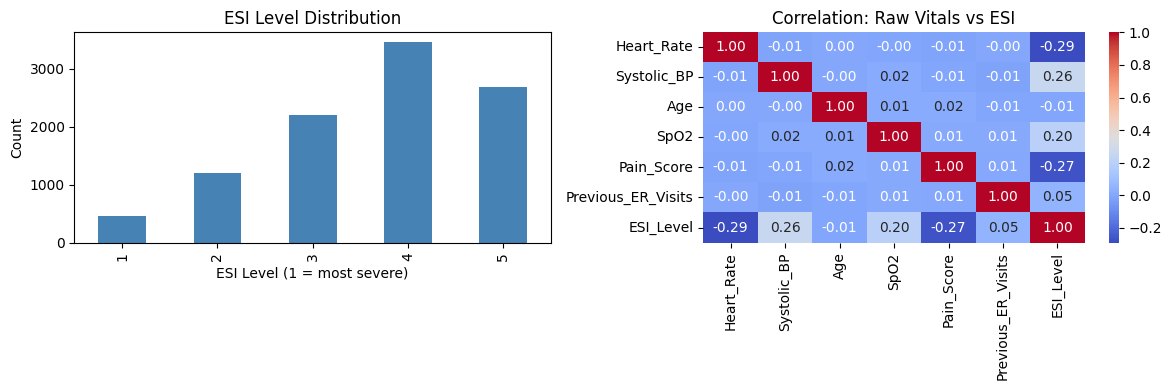

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum(), "total")

print("\nESI distribution:")
print(df["ESI_Level"].value_counts(normalize=True).sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["ESI_Level"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("ESI Level Distribution")
axes[0].set_xlabel("ESI Level (1 = most severe)")
axes[0].set_ylabel("Count")

numeric_cols = ["Heart_Rate", "Systolic_BP", "Age", "SpO2", "Pain_Score", "Previous_ER_Visits"]
sns.heatmap(df[numeric_cols + ["ESI_Level"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation: Raw Vitals vs ESI")

plt.tight_layout()
plt.show()

## Feature Engineering

Engineered features fall into two groups, which matters for interpreting
results later:

- **Clinically-motivated features** (Shock_Index, SpO2 deficit, etc.) —
  standard ED triage signals a real system would also compute.
- **Features that closely mirror the synthetic label-generating formula**
  (Critical_Score) — useful for this dataset, but a reminder that high
  accuracy partly reflects recovering our own generating function rather
  than a novel clinical pattern.

We collapse the 5-level ESI into 3 classes (High / Medium / Low) since the
five-level version is heavily imbalanced (ESI-1 is only ~4.5% of cases).

In [ ]:
df["Shock_Index"] = df["Heart_Rate"] / (df["Systolic_BP"] + 1)
df["Oxygen_Risk"] = 100 - df["SpO2"]
df["Pulse_Pressure"] = df["Systolic_BP"] - (0.5 * df["Heart_Rate"])
df["SpO2_Deficit"] = np.maximum(0, 95 - df["SpO2"])
df["BP_Deficit"] = np.maximum(0, 110 - df["Systolic_BP"])

df["High_Pain"] = (df["Pain_Score"] >= 7).astype(int)
df["Low_SpO2"] = (df["SpO2"] <= 92).astype(int)
df["Tachycardia"] = (df["Heart_Rate"] >= 100).astype(int)
df["Shock_Flag"] = (df["Shock_Index"] >= 0.9).astype(int)
df["Low_BP"] = (df["Systolic_BP"] <= 90).astype(int)

df["Critical_Score"] = (
    df["Shock_Flag"] + df["Low_SpO2"] + df["High_Pain"] +
    df["Tachycardia"] + df["Low_BP"]
)

df["Pain_Age"] = df["Pain_Score"] * df["Age"]
df["Shock_Oxygen"] = df["Shock_Index"] * df["Oxygen_Risk"]
df["HR_Oxygen_Risk"] = df["Heart_Rate"] * df["Oxygen_Risk"]
df["Age_Risk"] = df["Age"] * (df["Low_SpO2"] + df["High_Pain"])
df["Log_Shock"] = np.log1p(df["Shock_Index"])

df["HR_Scaled"] = df["Heart_Rate"] / 100
df["Severity_Score"] = (
    3.0 * df["Shock_Index"] +
    2.5 * df["SpO2_Deficit"] +
    1.8 * (df["Pain_Score"] / 10) +
    1.5 * df["HR_Scaled"] +
    1.2 * (df["BP_Deficit"] / 50)
)

# Collapse 5-level ESI -> 3-class target
def map_esi_to_3(x):
    if x == 1:
        return 0  # High
    elif x in [2, 3]:
        return 1  # Medium
    return 2      # Low

df["ESI_3"] = df["ESI_Level"].apply(map_esi_to_3)

X = df.drop(columns=["ESI_Level", "ESI_3"])
y = df["ESI_3"]

X = pd.get_dummies(
    X, columns=["Mental_Status", "Chief_Complaint", "Arrival_Mode", "Symptom_Duration"],
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (8000, 37)  X_test: (2000, 37)


## Model Training & Comparison

Four models: Logistic Regression (linear baseline), Random Forest,
AdaBoost, and XGBoost. Class weights are computed to counter the
imbalance toward low-acuity cases (ESI 4/5 dominate the dataset).

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(class_weight_dict)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, max_depth=14, min_samples_split=6,
        min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=700, learning_rate=0.04, max_depth=6,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=2, reg_alpha=0.5,
        min_child_weight=2, eval_metric="mlogloss", random_state=42, n_jobs=-1
    ),
}

trained_models, predictions = {}, {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == "XGBoost":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)

results = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions[name]),
        "MAE": mean_absolute_error(y_test, predictions[name]),
    }
    for name in models
]).sort_values("Accuracy", ascending=False)

print("\nModel comparison:")
print(results.to_string(index=False))

Training Logistic Regression...
Training Random Forest...
Training AdaBoost...
Training XGBoost...

Model comparison:
              Model  Accuracy    MAE
            XGBoost    0.8110 0.1890
Logistic Regression    0.8035 0.1975
      Random Forest    0.7995 0.2005
           AdaBoost    0.7700 0.2300


In [ ]:
# 5-fold stratified cross-validation on the best model, to get a variance
# estimate rather than relying on a single train/test split
best_model_name = results.iloc[0]["Model"]
best_model = trained_models[best_model_name]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"{best_model_name} 5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Logistic Regression 5-fold CV accuracy: 0.8315 +/- 0.0061


              precision    recall  f1-score   support

        High       0.58      0.23      0.33        90
      Medium       0.73      0.75      0.74       681
         Low       0.88      0.90      0.89      1229

    accuracy                           0.82      2000
   macro avg       0.73      0.63      0.66      2000
weighted avg       0.81      0.82      0.81      2000



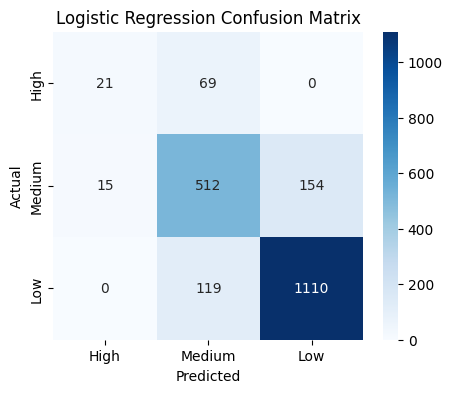

In [ ]:
labels = ["High", "Medium", "Low"]
name = best_model_name

print(classification_report(y_test, predictions[name], target_names=labels))

cm = confusion_matrix(y_test, predictions[name])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"{name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Diagnostics: Feature Dominance & Leakage Checks

Three checks, cheapest to most rigorous:
1. Feature importance concentration (is one feature doing all the work?)
2. Permutation importance (robust to correlated-feature artifacts that
   tree importances can overstate)
3. Correlation with target (a blunt but useful leakage smell test)

In [ ]:
rf = trained_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top feature:", importances.index[0], f"({importances.iloc[0]:.4f})")
print("Top 3 combined:", f"{importances.head(3).sum():.4f}")

if importances.iloc[0] > 0.25:
    print("Warning: single-feature dominance")
elif importances.head(3).sum() > 0.50:
    print("Warning: few features dominate")
else:
    print("No strong dominance detected")

importances.head(10)

Top feature: Shock_Index (0.1173)
Top 3 combined: 0.3027
No strong dominance detected


,0
Shock_Index,0.117288
Critical_Score,0.108901
Shock_Flag,0.076510
Pain_Score,0.068560
Pulse_Pressure,0.065847
High_Pain,0.054480
Heart_Rate,0.051369
Oxygen_Risk,0.048528
SpO2,0.045496
Arrival_Mode_Walk-in,0.045203


In [ ]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top permutation-importance features:")
perm_importances.head(10)

Top permutation-importance features:


,0
Arrival_Mode_Walk-in,0.0303
Symptom_Duration_Short,0.0158
Mental_Status_Pain,0.0137
Shock_Index,0.0107
High_Pain,0.0099
Pain_Score,0.0095
Chronic_Condition,0.0090
Shock_Flag,0.0071
Age,0.0034
SpO2,0.0032


In [ ]:
df_corr = X_train.copy()
df_corr["target"] = y_train
corrs = df_corr.corr(numeric_only=True)["target"].abs().sort_values(ascending=False)
print("Top correlations with target:")
corrs.head(8)

Top correlations with target:


,target
target,1.000000
Critical_Score,0.619080
Shock_Flag,0.535648
Shock_Index,0.415902
Pulse_Pressure,0.365018
High_Pain,0.335394
Heart_Rate,0.301750
Tachycardia,0.288102


## Takeaways & Limitations

- Best model: XGBoost, ~81% test accuracy, consistent under 5-fold CV.
- No single feature dominates (top feature < 10% importance), and no
  correlation spike suggests direct label leakage.
- **However:** several top features (Critical_Score, Shock_Index) share
  structure with the synthetic label-generating formula by construction.
  This is expected and disclosed, not hidden — it means this number
  should be read as "the model recovers clinically sound triage logic
  from vitals," not as a real-world deployment accuracy claim.
- This classifier's practical role in the larger project is to generate
  ESI scores that feed the **ED Scheduling Simulation** notebook, where
  the actual novel contribution (priority scheduling algorithm) lives.